# TIỀN XỬ LÝ DỮ LIỆU ẢNH SỐ
## New Plant Diseases Dataset
---
## A. Phân tích thống kê tập dữ liệu

### Tổng quan
Tập dữ liệu này bao gồm các hình ảnh lá cà chua được thu thập nhằm phục vụ bài toán phân loại bệnh cây trồng. Mỗi ảnh được gán nhãn tương ứng với tình trạng của lá, bao gồm các lớp bệnh khác nhau và lớp lá khỏe mạnh.  
Tập dữ liệu bao gồm:
- **images**: Các ảnh RGB của lá cà chua.
- **class_folders**: Gồm 5 lớp, bao gồm healthy và 4 loại bệnh.
    - Tomato___healthy
    - Tomato___Leaf_Mold
    - Tomato___Late_blight
    - Tomato___Early_blight
    - Tomato___Bacterial_spot
- **labels.csv**: Tệp chứa thông tin ánh xạ giữa tên ảnh và nhãn tương ứng. File này cho phép liên kết các ảnh trong thư mục `images/` với nhãn phân loại, phục vụ cho việc huấn luyện và phân tích dữ liệu.

Phân bố dữ liệu giữa các lớp tương đối đồng đều, giúp hạn chế vấn đề mất cân bằng lớp trong quá trình huấn luyện. Ngoài ra, các ảnh có sự đa dạng về điều kiện ánh sáng, màu sắc và hình dạng lá, phản ánh tính thực tế của dữ liệu.
### Nội dung thực hiện
1. Phân phối giá trị pixel toàn tập theo từng kênh màu (Histogram + KDE)
2. Phân tích mất cân bằng lớp (Class Imbalance)
3. Phát hiện ảnh trùng / gần trùng bằng **perceptual hash (pHash)**
4. Phân tích **độ sáng** và **độ tương phản** toàn cục theo từng lớp bằng **mean intensity** và **standard deviation**.
### Import thư viện

In [ ]:
import os
from pathlib import Path
from collections import Counter, defaultdict
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


### Load data

In [ ]:
labels_path = Path("data/labels.csv")
image_root = Path("data/images")

labels_df = pd.read_csv(labels_path)
labels_df["image_path"] = labels_df["image"].apply(lambda x: image_root / x)

print("Số mẫu:", len(labels_df))
print("Số lớp:", labels_df["label"].nunique())
labels_df.head()

Số mẫu: 6000
Số lớp: 5


,image,label,original_image,image_path
0,img_00001.jpg,Tomato___Bacterial_spot,bcffc5ba-6602-455f-a84c-eb0ad85672bc___UF.GRC_...,data/images/img_00001.jpg
1,img_00002.jpg,Tomato___Bacterial_spot,2f3e2c44-a83b-4f72-a831-ac42aec1020e___UF.GRC_...,data/images/img_00002.jpg
2,img_00003.jpg,Tomato___healthy,0c4b06d5-4053-44fc-99b6-504934fdd3a9___GH_HL L...,data/images/img_00003.jpg
3,img_00004.jpg,Tomato___Leaf_Mold,ebe5c5c5-7e29-4aa7-bc0b-f895b5bc3d20___Crnl_L....,data/images/img_00004.jpg
4,img_00005.jpg,Tomato___Leaf_Mold,bc374eed-3802-4ffe-9339-47e04a74a648___Crnl_L....,data/images/img_00005.jpg


### 1. Phân phối giá trị pixel trên toàn tập theo từng kênh màu
#### Mục tiêu
- Histogram cho biết phân phối tần suất mức cường độ pixel.
- KDE (Kernel Density Estimation) cho biết dạng phân phối được làm mượt.
- Cần thực hiện **theo từng kênh màu** trên **toàn bộ tập dữ liệu**.
#### Phương pháp
- Đọc ảnh và chuyển tất cả về **RGB**
- Gom toàn bộ pixel của từng kênh **R, G, B**
- Vẽ:
  - Histogram mật độ
  - KDE mật độ
- Đồng thời lưu các thống kê số:
  - mean, std, min, max, median, quantiles

In [ ]:
# =========================
# Pixel distribution theo từng kênh màu
# =========================
MAX_IMAGES_FOR_PIXEL_ANALYSIS = None
PIXELS_PER_IMAGE_FOR_ANALYSIS = 5000  # giảm tải RAM

selected_df = labels_df if MAX_IMAGES_FOR_PIXEL_ANALYSIS is None else labels_df.head(MAX_IMAGES_FOR_PIXEL_ANALYSIS)

channel_values = {"R": [], "G": [], "B": []}
rng = np.random.default_rng(42)

for p in selected_df["image_path"]:
    with Image.open(p) as img:
        arr = np.array(img.convert("RGB"), dtype=np.uint8).reshape(-1, 3)

    sample_size = min(PIXELS_PER_IMAGE_FOR_ANALYSIS, len(arr))
    idx = rng.choice(len(arr), size=sample_size, replace=False)
    sampled = arr[idx]

    channel_values["R"].append(sampled[:, 0])
    channel_values["G"].append(sampled[:, 1])
    channel_values["B"].append(sampled[:, 2])

for ch in channel_values:
    channel_values[ch] = np.concatenate(channel_values[ch])

pixel_distribution_stats = {}
for ch, vals in channel_values.items():
    pixel_distribution_stats[ch] = {
        "n_pixels": int(vals.size),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "min": int(np.min(vals)),
        "q25": float(np.quantile(vals, 0.25)),
        "median": float(np.median(vals)),
        "q75": float(np.quantile(vals, 0.75)),
        "max": int(np.max(vals)),
    }

pixel_distribution_df = pd.DataFrame(pixel_distribution_stats).T
pixel_distribution_df

,n_pixels,mean,std,min,q25,median,q75,max
R,30000000.0,112.029608,50.655170,0.0,76.0,116.0,147.0,255.0
G,30000000.0,116.218069,46.032829,0.0,89.0,119.0,144.0,255.0
B,30000000.0,106.119692,53.217651,0.0,66.0,111.0,144.0,255.0


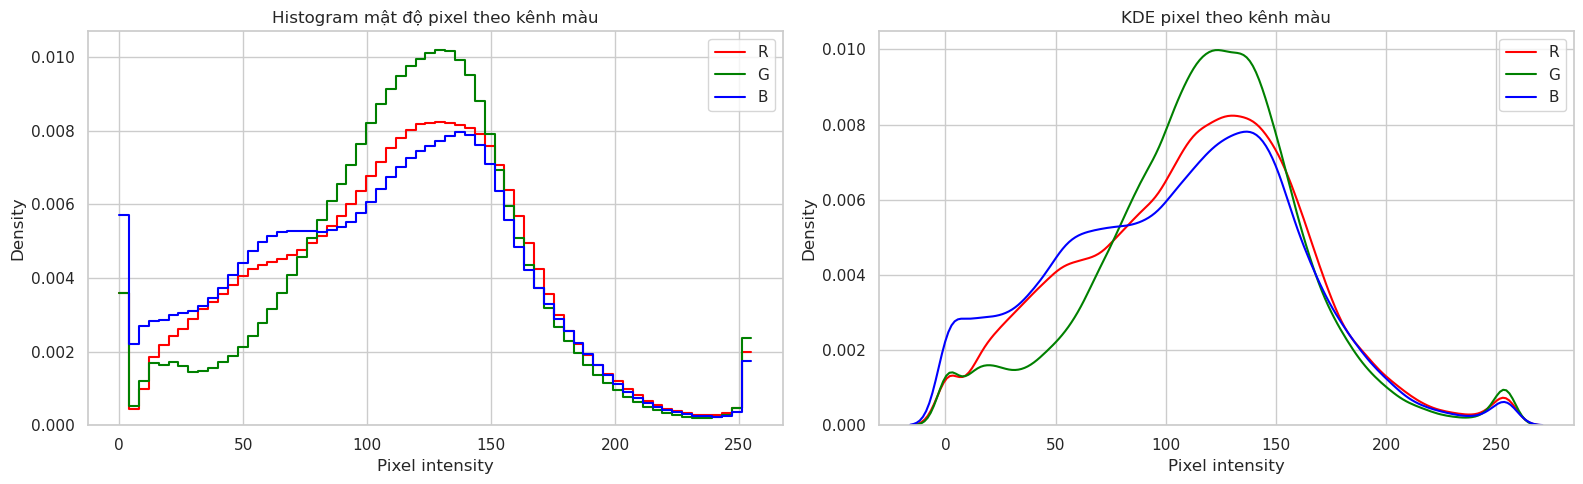

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
color_map = {"R": "red", "G": "green", "B": "blue"}

for ch in ["R", "G", "B"]:
    sns.histplot(
        channel_values[ch],
        bins=64,
        stat="density",
        element="step",
        fill=False,
        ax=axes[0],
        label=ch,
        color=color_map[ch]
    )
axes[0].set_title("Histogram mật độ pixel theo kênh màu")
axes[0].set_xlabel("Pixel intensity")
axes[0].set_ylabel("Density")
axes[0].legend()

for ch in ["R", "G", "B"]:
    vals = channel_values[ch]
    sample_size = min(100000, len(vals))
    sample_vals = rng.choice(vals, size=sample_size, replace=False)
    sns.kdeplot(sample_vals, ax=axes[1], label=ch, fill=False, color=color_map[ch])
axes[1].set_title("KDE pixel theo kênh màu")
axes[1].set_xlabel("Pixel intensity")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Nhận xét
1. Phân phối giá trị pixel theo ba kênh màu RGB cho thấy dữ liệu có xu hướng tập trung chủ yếu ở vùng **cường độ trung bình (mid-intensity range)**, khoảng từ 80 đến 160.  
2. Về giá trị trung bình:  
Kênh G (Green) có mean cao nhất ($\approx$116.22), tiếp theo là kênh R (Red) ($\approx$112.03) và thấp nhất là kênh B (Blue) ($\approx$106.12).   
Điều này cho thấy tập ảnh có xu hướng **thiên về màu xanh lá**, điều này hợp lý vì dữ liệu là ảnh lá cây.  
3. Về độ phân tán:  
Kênh B có độ lệch chuẩn cao nhất ($\approx$53.22), cho thấy mức độ biến thiên lớn hơn, tiếp theo là R ($\approx$50.66), thấp nhất là G ($\approx$46.03).  
Điều này cho thấy kênh xanh dương (B) có sự biến động ánh sáng mạnh hơn, trong khi kênh xanh lá (G) ổn định hơn.
4. Quan sát từ histogram và KDE:
- Cả ba kênh đều có dạng phân phối **lệch nhẹ về phía vùng sáng**, với đỉnh chính nằm khoảng **120-140**.
- Phân phối của các kênh tương đối giống nhau, tuy nhiên:
    - Kênh G có đỉnh cao hơn → tập trung mật độ nhiều hơn ở vùng trung bình
    - Kênh B có phần phân phối trải rộng hơn ở vùng thấp (0-80)
5. Ngoài ra, sự xuất hiện của giá trị min = 0 và max = 255 ở cả ba kênh cho thấy dữ liệu bao phủ toàn bộ dải dynamic range, tuy nhiên mật độ ở hai đầu này rất thấp.  
#### Kết luận
- Tập dữ liệu có phân phối pixel **tương đối cân bằng và ổn định**, không có hiện tượng lệch mạnh về phía vùng tối hoặc vùng sáng.
- Ba kênh màu có phân phối tương đối tương đồng, tuy nhiên vẫn tồn tại sự khác biệt nhẹ, trong đó kênh G chiếm ưu thế. Điều này phản ánh đặc trưng màu sắc tự nhiên của lá cây trong tập dữ liệu.

### 2. Phân tích mất cân bằng lớp (class imbalance)
#### Mục tiêu
- Tính tỉ lệ mỗi lớp
- Kiểm tra xem có lớp nào chiếm tỉ lệ **vượt mức 3×** so với lớp ít nhất không
#### Các biến sử dụng
- `class_count`
- `class_ratio`
- `max_min_ratio = max_count / min_count`
- Cờ logic: `has_severe_imbalance_3x`

In [ ]:
# =========================
# Class imbalance
# =========================
class_counts = labels_df["label"].value_counts().sort_values(ascending=False)
class_ratios = class_counts / class_counts.sum()

max_count = int(class_counts.max())
min_count = int(class_counts.min())
max_min_ratio = float(max_count / min_count)

largest_class = class_counts.idxmax()
smallest_class = class_counts.idxmin()

print(f"Lớp nhiều ảnh nhất: {largest_class} ({max_count})")
print(f"Lớp ít ảnh nhất: {smallest_class} ({min_count})")

has_severe_imbalance_3x = bool(max_min_ratio > 3)

class_imbalance_df = pd.DataFrame({
    "class_count": class_counts,
    "class_ratio": class_ratios,
    "class_percent": class_ratios * 100
})

class_imbalance_df

imbalance_summary = {
    "max_count": max_count,
    "min_count": min_count,
    "max_min_ratio": max_min_ratio,
    "has_severe_imbalance_3x": has_severe_imbalance_3x,
}
print(imbalance_summary)

Lớp nhiều ảnh nhất: Tomato___healthy (1249)
Lớp ít ảnh nhất: Tomato___Bacterial_spot (1109)
{'max_count': 1249, 'min_count': 1109, 'max_min_ratio': 1.1262398557258793, 'has_severe_imbalance_3x': False}


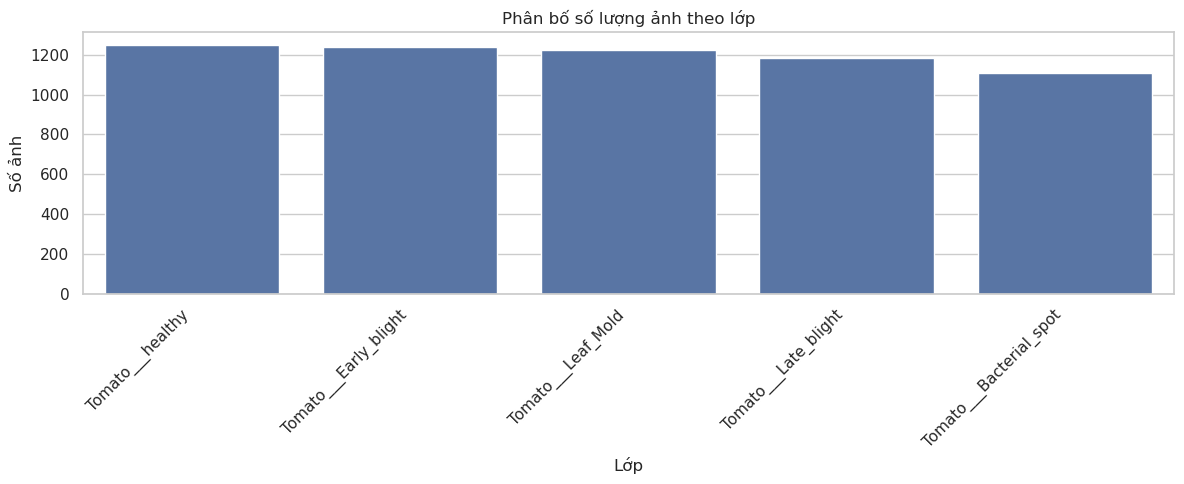

In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Phân bố số lượng ảnh theo lớp")
plt.xlabel("Lớp")
plt.ylabel("Số ảnh")
plt.tight_layout()
plt.show()

#### Nhận xét
Kết quả cho thấy tập dữ liệu bao gồm 5 lớp với số lượng ảnh phân bố khá đồng đều giữa các lớp.  
Cụ thể:
- Lớp có số lượng ảnh lớn nhất là Tomato___healthy với 1249 ảnh,
- Lớp có số lượng ảnh nhỏ nhất là Tomato___Bacterial_spot với 1109 ảnh.

Tỷ lệ giữa lớp lớn nhất và lớp nhỏ nhất là:
> max_min_ratio $\approx$1.13  

Giá trị này **nhỏ hơn ngưỡng 3×**, do đó:  
→ Tập dữ liệu không có hiện tượng mất cân bằng lớp nghiêm trọng theo tiêu chí ban đầu.
#### Kết luận
- Các lớp có số lượng ảnh tương đối tương đương nhau
- Không có lớp nào chiếm ưu thế vượt trội.

### 3. Phát hiện ảnh trùng lặp / gần trùng bằng perceptual hash (pHash)

#### Ý nghĩa
Ảnh trùng hoặc gần trùng có thể làm dữ liệu bị dư thừa và làm sai lệch kết quả huấn luyện, đặc biệt nếu các ảnh rất giống nhau xuất hiện ở cả tập train và test. Vì vậy, cần kiểm tra mức độ lặp trong tập dữ liệu trước khi tiền xử lý.

#### Nguyên lý
Perceptual hash (pHash) không so sánh từng pixel tuyệt đối mà mô tả **đặc trưng cảm nhận tổng quát** của ảnh. Trong notebook, ảnh được chuyển sang grayscale, resize về kích thước nhỏ, áp dụng DCT và giữ lại thành phần tần số thấp để tạo ra một chuỗi bit đại diện cho nội dung ảnh.

#### Quy ước so sánh
Độ giống nhau giữa hai ảnh được đo bằng **Hamming distance** giữa hai pHash:
- `Hamming distance = 0`: ảnh trùng hoàn toàn theo pHash
- `Hamming distance <= threshold`: ảnh gần trùng

Ngưỡng này có thể điều chỉnh tùy mức độ nghiêm ngặt mong muốn.

#### Cách thực hiện
1. Tính pHash cho từng ảnh
2. Gom các ảnh có cùng pHash để tìm **exact duplicates**
3. So sánh Hamming distance trong các nhóm ứng viên để tìm **near-duplicates**

#### Mục đích
Bước này giúp:
- đánh giá mức độ lặp của dữ liệu,
- loại bỏ ảnh dư thừa nếu cần,
- và giảm nguy cơ **data leakage** ở các bước huấn luyện và đánh giá sau đó.

In [ ]:
# =========================
# pHash implementation bằng numpy + Pillow
# =========================
from scipy.fftpack import dct

def phash_from_path(image_path, hash_size=8, highfreq_factor=4):
    img_size = hash_size * highfreq_factor

    with Image.open(image_path) as img:
        img = img.convert("L").resize((img_size, img_size), Image.Resampling.LANCZOS)
        pixels = np.asarray(img, dtype=np.float32)

    dct_rows = dct(pixels, axis=0, norm="ortho")
    dct_full = dct(dct_rows, axis=1, norm="ortho")
    dct_lowfreq = dct_full[:hash_size, :hash_size]

    # bỏ DC term [0,0] khi tính median để ổn định hơn
    dct_flat = dct_lowfreq.flatten()
    med = np.median(dct_flat[1:])
    diff = dct_lowfreq > med

    return diff.flatten().astype(np.uint8)

def hash_to_hex(hash_bits):
    bit_string = "".join(hash_bits.astype(str))
    return f"{int(bit_string, 2):016x}"

def hamming_distance(bits1, bits2):
    return int(np.count_nonzero(bits1 != bits2))


In [ ]:
# Tính pHash cho toàn bộ ảnh
phash_bits_list = []
phash_hex_list = []

for p in labels_df["image_path"]:
    bits = phash_from_path(p)
    phash_bits_list.append(bits)
    phash_hex_list.append(hash_to_hex(bits))

labels_df["phash_bits"] = phash_bits_list
labels_df["phash_hex"] = phash_hex_list

print("Đã tính pHash cho", len(labels_df), "ảnh")


Đã tính pHash cho 6000 ảnh


In [ ]:
# Exact duplicate theo pHash
phash_groups = labels_df.groupby("phash_hex").agg(
    n_images=("image", "count"),
    labels=("label", lambda x: list(x)),
    images=("image", lambda x: list(x)),
    paths=("image_path", lambda x: list(x)),
).reset_index()

exact_dup_groups = phash_groups[phash_groups["n_images"] > 1].copy()
n_exact_duplicate_groups = int(len(exact_dup_groups))
n_images_in_exact_duplicate_groups = int(exact_dup_groups["n_images"].sum())
n_redundant_exact_duplicates = int((exact_dup_groups["n_images"] - 1).sum())

exact_duplicate_ratio = float(n_redundant_exact_duplicates / len(labels_df))

exact_duplicate_summary = {
    "n_exact_duplicate_groups": n_exact_duplicate_groups,
    "n_images_in_exact_duplicate_groups": n_images_in_exact_duplicate_groups,
    "n_redundant_exact_duplicates": n_redundant_exact_duplicates,
    "exact_duplicate_ratio": exact_duplicate_ratio,
}

print(exact_duplicate_summary)
exact_dup_groups.head(10)

{'n_exact_duplicate_groups': 2, 'n_images_in_exact_duplicate_groups': 4, 'n_redundant_exact_duplicates': 2, 'exact_duplicate_ratio': 0.0003333333333333333}


,phash_hex,n_images,labels,images,paths
254,8cf3f6ca1a0dc13c,2,"[Tomato___healthy, Tomato___healthy]","[img_01480.jpg, img_04893.jpg]","[data/images/img_01480.jpg, data/images/img_04..."
3227,cd92306d63933c6d,2,"[Tomato___Late_blight, Tomato___Late_blight]","[img_01372.jpg, img_05581.jpg]","[data/images/img_01372.jpg, data/images/img_05..."


In [ ]:
# Near-duplicate theo Hamming distance
# Để giảm độ phức tạp, chỉ so sánh trên các ảnh có cùng 16 bit đầu của hash hex (blocking)
NEAR_DUP_THRESHOLD = 6

labels_df["phash_prefix"] = labels_df["phash_hex"].str[:4]

near_duplicate_pairs = []

for _, block in labels_df.groupby("phash_prefix"):
    idxs = block.index.tolist()
    if len(idxs) < 2:
        continue

    bits_map = {i: labels_df.at[i, "phash_bits"] for i in idxs}

    for i_pos in range(len(idxs)):
        for j_pos in range(i_pos + 1, len(idxs)):
            i = idxs[i_pos]
            j = idxs[j_pos]
            dist = hamming_distance(bits_map[i], bits_map[j])
            if dist <= NEAR_DUP_THRESHOLD:
                near_duplicate_pairs.append({
                    "idx_1": int(i),
                    "idx_2": int(j),
                    "image_1": labels_df.at[i, "image"],
                    "image_2": labels_df.at[j, "image"],
                    "label_1": labels_df.at[i, "label"],
                    "label_2": labels_df.at[j, "label"],
                    "path_1": labels_df.at[i, "image_path"],
                    "path_2": labels_df.at[j, "image_path"],
                    "hamming_distance": int(dist),
                })

near_duplicate_pairs_df = pd.DataFrame(near_duplicate_pairs)

if len(near_duplicate_pairs_df) > 0:
    involved_images = set(near_duplicate_pairs_df["image_1"]).union(set(near_duplicate_pairs_df["image_2"]))
    near_duplicate_ratio = len(involved_images) / len(labels_df)
else:
    near_duplicate_ratio = 0.0

near_duplicate_summary = {
    "near_dup_threshold": NEAR_DUP_THRESHOLD,
    "n_near_duplicate_pairs": int(len(near_duplicate_pairs_df)),
    "near_duplicate_ratio": float(near_duplicate_ratio),
}

print(near_duplicate_summary)
near_duplicate_pairs_df.head(20)

{'near_dup_threshold': 6, 'n_near_duplicate_pairs': 20, 'near_duplicate_ratio': 0.005166666666666667}


,idx_1,idx_2,image_1,image_2,label_1,label_2,path_1,path_2,hamming_distance
0,183,4128,img_00184.jpg,img_04129.jpg,Tomato___healthy,Tomato___healthy,data/images/img_00184.jpg,data/images/img_04129.jpg,4
1,898,3693,img_00899.jpg,img_03694.jpg,Tomato___healthy,Tomato___healthy,data/images/img_00899.jpg,data/images/img_03694.jpg,6
2,4258,4314,img_04259.jpg,img_04315.jpg,Tomato___healthy,Tomato___healthy,data/images/img_04259.jpg,data/images/img_04315.jpg,6
3,429,3959,img_00430.jpg,img_03960.jpg,Tomato___healthy,Tomato___healthy,data/images/img_00430.jpg,data/images/img_03960.jpg,6
4,429,4114,img_00430.jpg,img_04115.jpg,Tomato___healthy,Tomato___healthy,data/images/img_00430.jpg,data/images/img_04115.jpg,4
5,429,4465,img_00430.jpg,img_04466.jpg,Tomato___healthy,Tomato___healthy,data/images/img_00430.jpg,data/images/img_04466.jpg,6
6,675,4465,img_00676.jpg,img_04466.jpg,Tomato___healthy,Tomato___healthy,data/images/img_00676.jpg,data/images/img_04466.jpg,6
7,3959,4114,img_03960.jpg,img_04115.jpg,Tomato___healthy,Tomato___healthy,data/images/img_03960.jpg,data/images/img_04115.jpg,6
8,3959,4465,img_03960.jpg,img_04466.jpg,Tomato___healthy,Tomato___healthy,data/images/img_03960.jpg,data/images/img_04466.jpg,4
9,4114,4465,img_04115.jpg,img_04466.jpg,Tomato___healthy,Tomato___healthy,data/images/img_04115.jpg,data/images/img_04466.jpg,6


In [ ]:
# Xử lý duplicate: giữ lại ảnh đầu tiên trong mỗi nhóm exact duplicate
duplicate_keep_mask = np.ones(len(labels_df), dtype=bool)
exact_duplicate_removed_files = []

for _, row in exact_dup_groups.iterrows():
    paths = row["paths"]
    # giữ ảnh đầu tiên, loại các ảnh còn lại
    for p in paths[1:]:
        idx = labels_df.index[labels_df["image_path"] == p]
        duplicate_keep_mask[np.isin(labels_df.index, idx)] = False
        exact_duplicate_removed_files.append(p)

deduplicated_df = labels_df.loc[duplicate_keep_mask].copy()

dedup_handling_summary = {
    "n_before_dedup": int(len(labels_df)),
    "n_after_exact_dedup": int(len(deduplicated_df)),
    "n_removed_exact_duplicates": int(len(labels_df) - len(deduplicated_df)),
}

print(dedup_handling_summary)

{'n_before_dedup': 6000, 'n_after_exact_dedup': 5998, 'n_removed_exact_duplicates': 2}


#### Nhận xét

Kết quả cho thấy tập dữ liệu có mức độ trùng lặp rất thấp. Cụ thể, chỉ phát hiện **2 nhóm exact duplicate**, tương ứng **2 ảnh dư thừa** trên tổng số 6000 ảnh, với tỷ lệ khoảng **0.033%**. Các ảnh trùng hoàn toàn đều xuất hiện trong cùng một lớp, nên không gây sai lệch nhãn nhưng vẫn cần loại bỏ để tránh dư thừa dữ liệu.

Với ngưỡng `Hamming distance <= 6`, hệ thống phát hiện **20 cặp near-duplicate**, tương ứng khoảng **0.52%** số ảnh có liên quan đến ít nhất một cặp gần trùng. Các cặp này chủ yếu xuất hiện trong cùng một lớp, đặc biệt ở lớp **Tomato___healthy**, cho thấy đây thường là các ảnh rất giống nhau về nội dung và chỉ khác nhẹ về góc chụp, ánh sáng hoặc mức nén.

Trong bước làm sạch dữ liệu, nhóm giữ lại ảnh đầu tiên trong mỗi nhóm exact duplicate và loại bỏ **2 ảnh dư thừa**, làm số lượng ảnh giảm từ **6000** xuống **5998**. Đối với near-duplicate, do tỷ lệ thấp và vẫn phản ánh biến thiên tự nhiên của dữ liệu, nhóm giữ lại để bảo toàn độ đa dạng của tập ảnh. Nhìn chung, tập dữ liệu không có dấu hiệu lặp nghiêm trọng và có chất lượng đủ tốt cho các bước tiền xử lý và huấn luyện tiếp theo.

### 4. Phân tích độ sáng và độ tương phản toàn cục theo lớp

#### Mục tiêu
- Tính **mean intensity**
- Tính **standard deviation intensity**
- Phân tích **theo lớp**
- Trực quan hóa bằng **boxplot**

#### Phương pháp
Mỗi ảnh được chuyển sang grayscale:
- `mean_intensity = mean(pixel)`
- `std_intensity = std(pixel)`

Sau đó gom theo lớp để:
- tính thống kê mô tả
- vẽ boxplot phân lớp


In [ ]:
# =========================
# Brightness & contrast by class
# =========================
brightness_contrast_records = []

for _, row in deduplicated_df.iterrows():
    with Image.open(row["image_path"]) as img:
        gray = np.asarray(img.convert("L"), dtype=np.float32)
        brightness_contrast_records.append({
            "image": row["image"],
            "label": row["label"],
            "mean_intensity": float(gray.mean()),
            "std_intensity": float(gray.std()),
        })

brightness_contrast_df = pd.DataFrame(brightness_contrast_records)

per_class_intensity_summary = brightness_contrast_df.groupby("label").agg(
    n_images=("image", "count"),
    mean_intensity_mean=("mean_intensity", "mean"),
    mean_intensity_std=("mean_intensity", "std"),
    std_intensity_mean=("std_intensity", "mean"),
    std_intensity_std=("std_intensity", "std"),
    mean_intensity_median=("mean_intensity", "median"),
    std_intensity_median=("std_intensity", "median"),
).sort_values("n_images", ascending=False)

per_class_intensity_summary

,n_images,mean_intensity_mean,mean_intensity_std,std_intensity_mean,std_intensity_std,mean_intensity_median,std_intensity_median
label,,,,,,,
Tomato___healthy,1248,123.593974,32.525406,41.286435,13.537657,116.391899,45.603230
Tomato___Early_blight,1236,110.916747,14.286501,46.582240,11.023166,109.927490,46.659391
Tomato___Leaf_Mold,1221,115.273464,12.640901,36.685751,9.168225,116.371948,37.185432
Tomato___Late_blight,1184,113.331441,28.905680,38.941523,14.997529,118.961769,39.322121
Tomato___Bacterial_spot,1109,104.966002,10.648671,33.336941,5.958930,103.089859,33.659004


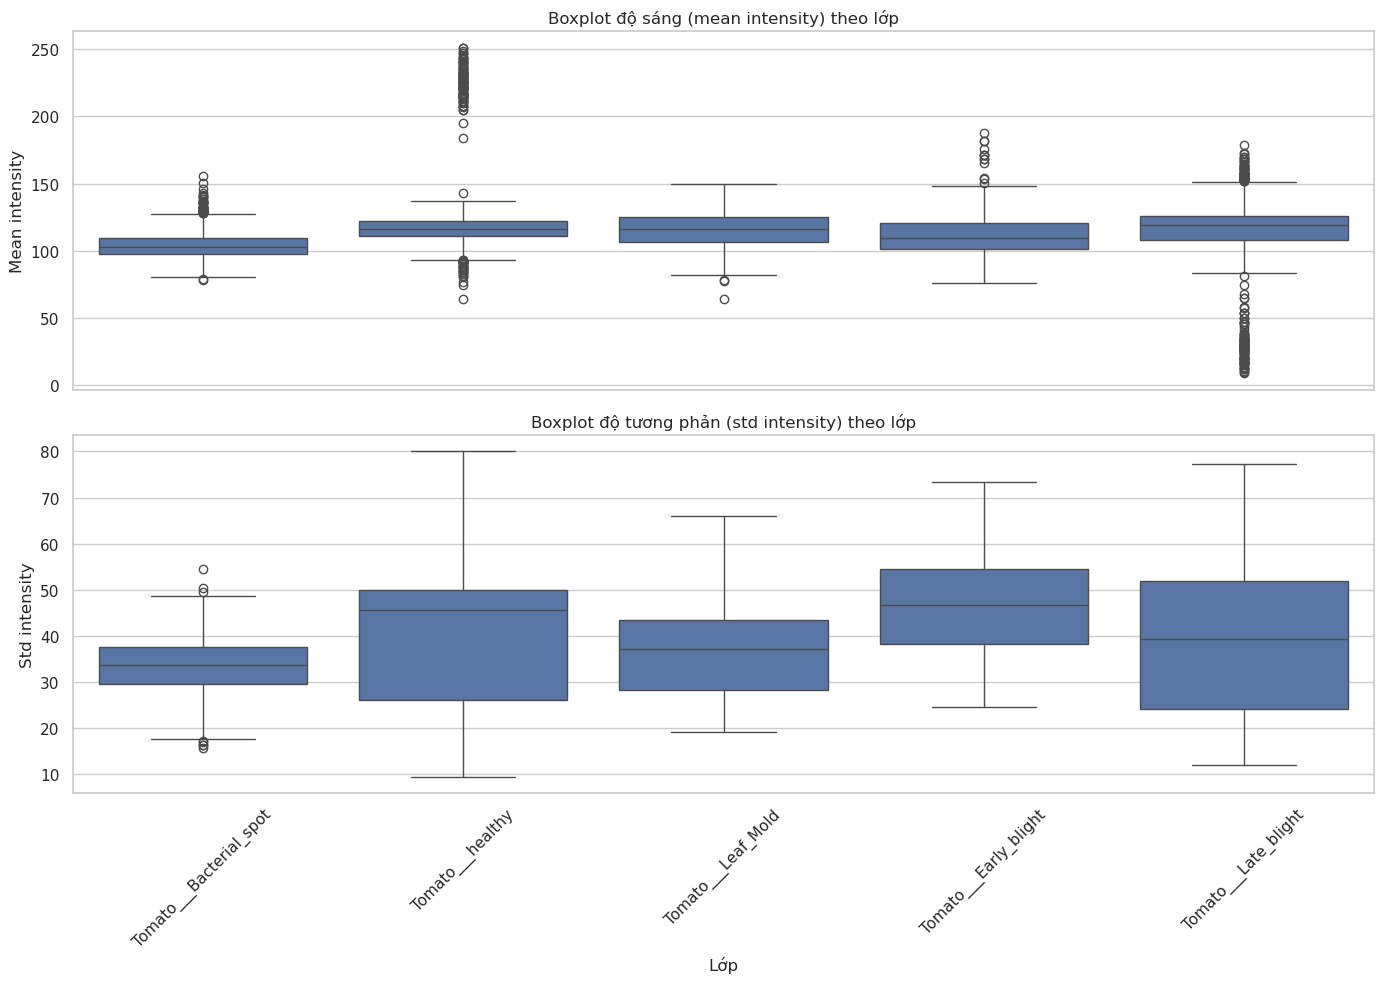

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

sns.boxplot(data=brightness_contrast_df, x="label", y="mean_intensity", ax=axes[0])
axes[0].set_title("Boxplot độ sáng (mean intensity) theo lớp")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean intensity")
axes[0].tick_params(axis="x", rotation=60)

sns.boxplot(data=brightness_contrast_df, x="label", y="std_intensity", ax=axes[1])
axes[1].set_title("Boxplot độ tương phản (std intensity) theo lớp")
axes[1].set_xlabel("Lớp")
axes[1].set_ylabel("Std intensity")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


#### Nhận xét

Kết quả cho thấy độ sáng (mean intensity) có sự khác biệt giữa các lớp. Cụ thể, lớp **Tomato___healthy** có độ sáng trung bình cao nhất ($\approx$123.6), trong khi lớp **Tomato___Bacterial_spot** thấp nhất ($\approx$105). Điều này cho thấy lá khỏe thường sáng hơn, trong khi các lá bị bệnh có xu hướng tối hơn do tổn thương bề mặt.

Boxplot cũng cho thấy phân phối độ sáng giữa các lớp có sự chồng lấn nhưng vẫn tồn tại khác biệt nhất định. Một số lớp như **Late_blight** và **Leaf_Mold** có median khá gần nhau, cho thấy khó phân tách hoàn toàn chỉ dựa trên độ sáng.

Về độ tương phản (std intensity), lớp **Tomato___Early_blight** và **Tomato___healthy** có giá trị cao hơn ($\approx$41-46), trong khi lớp **Bacterial_spot** thấp nhất ($\approx$33). Điều này cho thấy các lớp có mức độ biến thiên pixel khác nhau, phản ánh sự khác biệt về texture và mức độ lan rộng của bệnh trên lá.

Ngoài ra, boxplot cho thấy tồn tại nhiều outliers, đặc biệt ở lớp **healthy** và **Late_blight**, cho thấy dữ liệu có sự đa dạng về điều kiện ánh sáng và chất lượng ảnh.

Nhìn chung, độ sáng và độ tương phản có khả năng cung cấp thông tin phân biệt giữa các lớp, nhưng không hoàn toàn tách biệt rõ ràng. Điều này gợi ý rằng trong bước tiền xử lý, có thể cần chuẩn hóa ánh sáng hoặc kết hợp thêm các đặc trưng khác để cải thiện hiệu quả mô hình.

### Bảng kết quả tổng hợp

In [ ]:
# =========================
# Tổng hợp các kết quả quan trọng
# =========================
final_summary_table = pd.DataFrame([
    {"metric": "n_images", "value": len(labels_df)},
    {"metric": "n_classes", "value": labels_df["label"].nunique()},
    {"metric": "class_max_count", "value": max_count},
    {"metric": "class_min_count", "value": min_count},
    {"metric": "class_max_min_ratio", "value": max_min_ratio},
    {"metric": "has_severe_imbalance_3x", "value": has_severe_imbalance_3x},
    {"metric": "n_exact_duplicate_groups", "value": n_exact_duplicate_groups},
    {"metric": "n_redundant_exact_duplicates", "value": n_redundant_exact_duplicates},
    {"metric": "exact_duplicate_ratio", "value": exact_duplicate_ratio},
    {"metric": "n_near_duplicate_pairs", "value": len(near_duplicate_pairs_df)},
    {"metric": "near_dup_threshold", "value": NEAR_DUP_THRESHOLD},
    {"metric": "n_after_exact_dedup", "value": len(deduplicated_df)},
])

final_summary_table

,metric,value
0,n_images,6000
1,n_classes,5
2,class_max_count,1249
3,class_min_count,1109
4,class_max_min_ratio,1.12624
5,has_severe_imbalance_3x,False
6,n_exact_duplicate_groups,2
7,n_redundant_exact_duplicates,2
8,exact_duplicate_ratio,0.000333
9,n_near_duplicate_pairs,20


### Phân tích kết quả tổng hợp

Bảng tổng hợp cho thấy tập dữ liệu gồm **6000 ảnh** thuộc **5 lớp**, với phân bố tương đối đồng đều (max/min ratio $\approx$ 1.13), không xuất hiện mất cân bằng lớp nghiêm trọng.

Phân tích pixel cho thấy dữ liệu có phân phối ánh sáng ổn định, không lệch mạnh về vùng tối hoặc sáng, và mang đặc trưng màu xanh lá rõ rệt.

Về chất lượng dữ liệu, số lượng ảnh trùng hoàn toàn rất thấp (**2 nhóm, 2 ảnh dư thừa**, $\approx$0.033%) và đã được loại bỏ. Ngoài ra, phát hiện **20 cặp near-duplicate** ($\approx$0.52%), cho thấy mức độ lặp không đáng kể.

Phân tích độ sáng và tương phản cho thấy tồn tại sự khác biệt nhất định giữa các lớp, tuy nhiên vẫn có sự chồng lấn, cho thấy các đặc trưng này chưa đủ để phân tách hoàn toàn.

→ Nhìn chung, tập dữ liệu có:
- phân bố lớp cân bằng,
- chất lượng tốt (ít duplicate),
- và độ đa dạng phù hợp.

Do đó, dữ liệu sẵn sàng cho bước tiền xử lý ở các phần tiếp theo.

---
## B. Các kỹ thuật tiền xử lý và phân tích tác động
### Nội dung thực hiện
1. Thay đổi kích thước ảnh và đo SSIM, PSNR  
2. Chuyển đổi không gian màu và so sánh bằng PCA explained variance  
3. Chuẩn hóa dữ liệu và đánh giá bằng KS test  
4. Data augmentation và so sánh phân phối đặc trưng bằng t-SNE  

Ngoài ra, phần này thực hiện ablation study bằng mô hình phân loại đơn giản (k-NN) để đo lường tác động của từng kỹ thuật đến hiệu quả phân loại.

### Import thư viện

In [ ]:
from PIL import ImageEnhance

import cv2

from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### Chuẩn bị dữ liệu cho phân tích

Trong phần này, hầu hết các phân tích định lượng được thực hiện trên toàn bộ tập dữ liệu sau khi loại bỏ ảnh trùng lặp (`deduplicated_df`) nhằm đảm bảo kết quả có tính đại diện và độ tin cậy cao.

Riêng đối với t-SNE, do chi phí tính toán lớn và mục tiêu chủ yếu là trực quan hóa phân phối đặc trưng, một tập mẫu cân bằng theo lớp được sử dụng để giảm thời gian xử lý nhưng vẫn đảm bảo tính đại diện cho dữ liệu tổng thể.

In [ ]:
full_df = deduplicated_df.copy()
SAMPLE_PER_CLASS = 150   # 5 lớp -> khoảng 750 ảnh

sample_df = (
    deduplicated_df.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), SAMPLE_PER_CLASS), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print("Kích thước sample_df:", len(sample_df))
print(sample_df["label"].value_counts())

Kích thước sample_df: 750
label
Tomato___Bacterial_spot    150
Tomato___Early_blight      150
Tomato___Late_blight       150
Tomato___Leaf_Mold         150
Tomato___healthy           150
Name: count, dtype: int64


In [ ]:
def read_rgb_image(path):
    with Image.open(path) as img:
        return np.array(img.convert("RGB"))

def resize_np(img, size):
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

def convert_color_space(img, mode):
    if mode == "rgb":
        return img
    elif mode == "gray":
        return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    elif mode == "hsv":
        return cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    elif mode == "lab":
        return cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    else:
        raise ValueError("mode phải là rgb, gray, hsv hoặc lab")

def flatten_image(arr):
    return arr.flatten().astype(np.float32)

def zscore_global(arr):
    arr = arr.astype(np.float32)
    mean = arr.mean()
    std = arr.std()
    if std == 0:
        std = 1.0
    return (arr - mean) / std

def zscore_channel(arr):
    arr = arr.astype(np.float32).copy()
    if arr.ndim == 2:
        mean = arr.mean()
        std = arr.std()
        if std == 0:
            std = 1.0
        return (arr - mean) / std

    for c in range(arr.shape[2]):
        mean = arr[:, :, c].mean()
        std = arr[:, :, c].std()
        if std == 0:
            std = 1.0
        arr[:, :, c] = (arr[:, :, c] - mean) / std
    return arr

def normalize_image(arr, method=None):
    arr = arr.astype(np.float32)

    if method is None:
        return arr

    if method == "minmax_01":
        return arr / 255.0

    if method == "minmax_m11":
        return (arr / 127.5) - 1.0

    if method == "zscore_global":
        return zscore_global(arr)

    if method == "zscore_channel":
        return zscore_channel(arr)

    raise ValueError("Phương pháp chuẩn hóa không hợp lệ")

def augment_image(img):
    """img là numpy RGB image"""
    pil_img = Image.fromarray(img)

    # 1. lật ngang
    if np.random.rand() < 0.5:
        pil_img = pil_img.transpose(Image.FLIP_LEFT_RIGHT)

    # 2. lật dọc
    if np.random.rand() < 0.3:
        pil_img = pil_img.transpose(Image.FLIP_TOP_BOTTOM)

    # 3. xoay
    angle = np.random.uniform(-20, 20)
    pil_img = pil_img.rotate(angle)

    # 4. cắt ngẫu nhiên rồi resize lại
    w, h = pil_img.size
    crop_ratio = np.random.uniform(0.8, 1.0)
    new_w, new_h = int(w * crop_ratio), int(h * crop_ratio)
    left = np.random.randint(0, w - new_w + 1)
    top = np.random.randint(0, h - new_h + 1)
    pil_img = pil_img.crop((left, top, left + new_w, top + new_h))
    pil_img = pil_img.resize((w, h))

    # 5. brightness
    pil_img = ImageEnhance.Brightness(pil_img).enhance(np.random.uniform(0.8, 1.2))

    # 6. contrast
    pil_img = ImageEnhance.Contrast(pil_img).enhance(np.random.uniform(0.8, 1.2))

    # 7. Gaussian noise
    arr = np.array(pil_img).astype(np.float32)
    noise = np.random.normal(0, 8, arr.shape)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)

    return arr

### 1. Resize và đánh giá mức độ mất mát thông tin bằng SSIM và PSNR
Trong phần này, ảnh được thay đổi về ba kích thước khác nhau gồm **32×32**, **64×64** và **128×128** để đánh giá ảnh hưởng của việc giảm kích thước đến chất lượng dữ liệu ảnh.

Với mỗi kích thước, ảnh được resize xuống kích thước tương ứng rồi resize ngược trở lại kích thước ban đầu trước khi so sánh với ảnh gốc. Mức độ mất mát thông tin được đo lường bằng hai chỉ số:
- **SSIM (Structural Similarity Index)**: đánh giá mức độ tương đồng về cấu trúc giữa ảnh gốc và ảnh sau resize
- **PSNR (Peak Signal-to-Noise Ratio)**: đo mức độ suy giảm chất lượng tín hiệu của ảnh sau resize so với ảnh gốc

In [ ]:
def compute_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(255.0 / np.sqrt(mse))

def compute_ssim(img1, img2):
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    C1 = (0.01 * 255) ** 2
    C2 = (0.03 * 255) ** 2

    if img1.ndim == 3:
        ssim_vals = []
        for i in range(3):
            ssim_vals.append(compute_ssim(img1[:, :, i], img2[:, :, i]))
        return np.mean(ssim_vals)

    mu1 = img1.mean()
    mu2 = img2.mean()

    sigma1 = img1.var()
    sigma2 = img2.var()
    sigma12 = ((img1 - mu1) * (img2 - mu2)).mean()

    numerator = (2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)
    denominator = (mu1**2 + mu2**2 + C1) * (sigma1 + sigma2 + C2)

    return numerator / denominator

In [ ]:
resize_sizes = [32, 64, 128]
resize_results = []

for size in resize_sizes:
    ssim_scores = []
    psnr_scores = []

    for _, row in full_df.iterrows():
        img = read_rgb_image(row["image_path"])
        h, w = img.shape[:2]

        img_small = resize_np(img, size)
        img_restored = cv2.resize(img_small, (w, h), interpolation=cv2.INTER_LINEAR)

        ssim_scores.append(compute_ssim(img, img_restored))
        psnr_scores.append(compute_psnr(img, img_restored))

    resize_results.append({
        "size": size,
        "mean_ssim": float(np.mean(ssim_scores)),
        "std_ssim": float(np.std(ssim_scores)),
        "mean_psnr": float(np.mean(psnr_scores)),
        "std_psnr": float(np.std(psnr_scores)),
    })

resize_metrics_df = pd.DataFrame(resize_results)
resize_metrics_df

,size,mean_ssim,std_ssim,mean_psnr,std_psnr
0,32,0.875144,0.093950,23.764583,3.703340
1,64,0.910321,0.078782,25.377949,4.035560
2,128,0.938599,0.061026,27.326582,4.594258


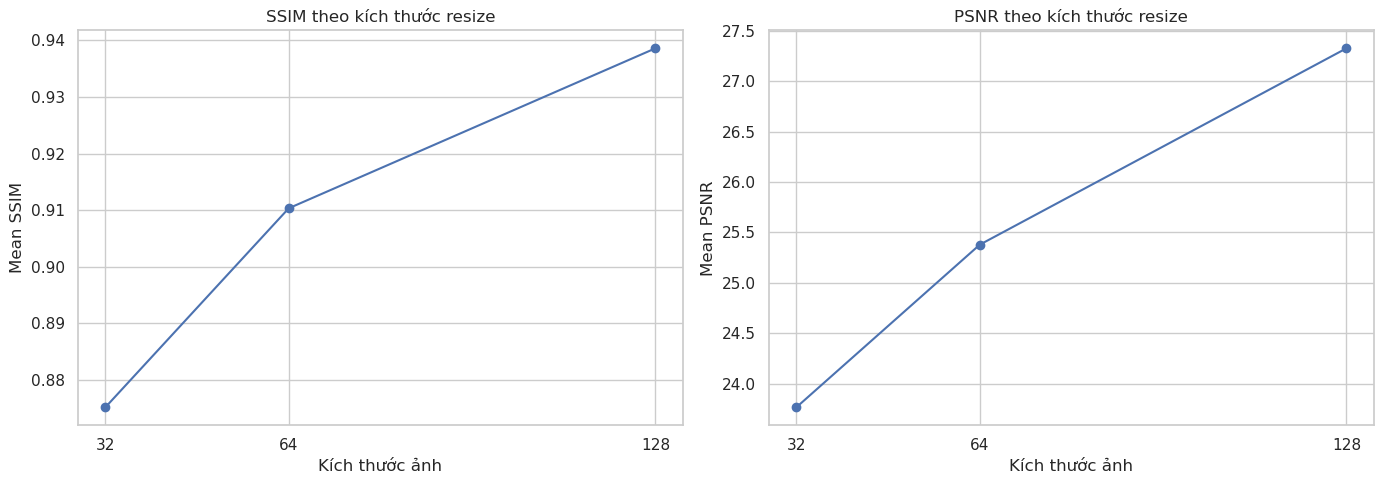

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SSIM plot
axes[0].plot(resize_metrics_df["size"], resize_metrics_df["mean_ssim"], marker="o")
axes[0].set_title("SSIM theo kích thước resize")
axes[0].set_xlabel("Kích thước ảnh")
axes[0].set_ylabel("Mean SSIM")
axes[0].set_xticks(resize_sizes)

# PSNR plot
axes[1].plot(resize_metrics_df["size"], resize_metrics_df["mean_psnr"], marker="o")
axes[1].set_title("PSNR theo kích thước resize")
axes[1].set_xlabel("Kích thước ảnh")
axes[1].set_ylabel("Mean PSNR")
axes[1].set_xticks(resize_sizes)

plt.tight_layout()
plt.show()

#### Nhận xét
Kết quả cho thấy giá trị SSIM và PSNR **tăng dần theo kích thước ảnh**.   
Cụ thể, khi giảm kích thước xuống **32×32**, SSIM đạt khoảng 0.875 và PSNR khoảng 23.76, cho thấy **sự mất mát đáng kể về cấu trúc và chất lượng ảnh**.  
Khi tăng lên **64×64**, các chỉ số được cải thiện (SSIM ≈ 0.91, PSNR ≈ 25.38), phản ánh **khả năng giữ lại thông tin tốt hơn**.
Ở kích thước **128×128**, SSIM đạt khoảng 0.94 và PSNR khoảng 27.33, cho thấy **mức độ bảo toàn cấu trúc và chất lượng cao nhất** trong các cấu hình đã thử.  
Đường cong SSIM theo kích thước thể hiện **xu hướng tăng rõ rệt**, chứng tỏ rằng việc **sử dụng kích thước ảnh lớn hơn** giúp **giảm thiểu mất mát thông tin** khi resize.   
Tuy nhiên, kích thước ảnh lớn cũng làm **tăng chi phí tính toán và bộ nhớ**.  
Do đó, **kích thước 128×128 được lựa chọn cho các bước tiếp theo** vì đạt được sự cân bằng hợp lý giữa khả năng bảo toàn thông tin (SSIM và PSNR cao) và chi phí tính toán.  
Kích thước này giữ lại phần lớn đặc trưng quan trọng của ảnh, đồng thời vẫn đảm bảo khả năng xử lý hiệu quả trong các bước phân tích và huấn luyện mô hình.

### 2. Chuyển đổi không gian màu và đánh giá bằng PCA

Ảnh được biểu diễn dưới bốn không gian màu gồm **RGB**, **Grayscale**, **HSV** và **LAB** nhằm so sánh mức độ bảo toàn thông tin của từng cách biểu diễn.

Với mỗi không gian màu, ảnh được resize về **64×64**, sau đó chuyển thành vector đặc trưng và đưa vào phân tích **PCA** với **50 thành phần chính**. Chỉ số sử dụng để so sánh là **tổng tỷ lệ phương sai giải thích** (*explained variance ratio sum*).

Không gian màu có giá trị explained variance cao hơn được xem là biểu diễn dữ liệu hiệu quả hơn trong không gian đặc trưng nén. Tuy nhiên, chỉ số này chủ yếu phản ánh khả năng nén thông tin của dữ liệu, không trực tiếp khẳng định khả năng phân loại tốt hơn.

In [ ]:
color_modes = ["rgb", "gray", "hsv", "lab"]
color_space_results = []

for mode in color_modes:
    X_mode = []

    for _, row in full_df.iterrows():
        img = read_rgb_image(row["image_path"])
        img = resize_np(img, 64)
        img = convert_color_space(img, mode)
        X_mode.append(flatten_image(img))

    X_mode = np.array(X_mode, dtype=np.float32)

    X_mode = StandardScaler().fit_transform(X_mode)

    pca = PCA(n_components=50, random_state=RANDOM_STATE)
    pca.fit(X_mode)

    color_space_results.append({
        "color_space": mode,
        "explained_variance_k50": float(pca.explained_variance_ratio_.sum())
    })

color_space_df = pd.DataFrame(color_space_results).sort_values(
    "explained_variance_k50", ascending=False
)

color_space_df

,color_space,explained_variance_k50
1,gray,0.805262
0,rgb,0.786718
3,lab,0.724356
2,hsv,0.663047


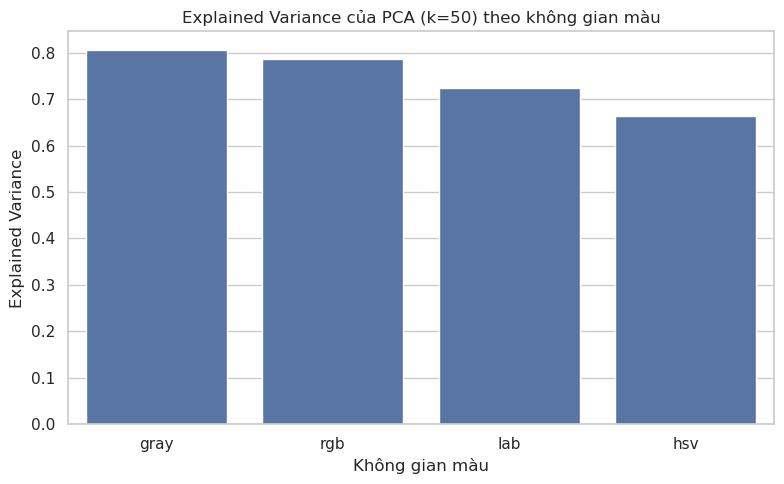

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=color_space_df, x="color_space", y="explained_variance_k50")
plt.title("Explained Variance của PCA (k=50) theo không gian màu")
plt.xlabel("Không gian màu")
plt.ylabel("Explained Variance")
plt.tight_layout()
plt.show()

#### Nhận xét

Kết quả sau khi chuẩn hóa cho thấy không gian **Grayscale** đạt giá trị explained variance cao nhất (**≈ 0.805**), tiếp theo là **RGB (≈ 0.787)**, **LAB (≈ 0.724)** và thấp nhất là **HSV (≈ 0.663)**. Điều này cho thấy dữ liệu trong không gian grayscale có thể được nén hiệu quả hơn bằng PCA với 50 thành phần chính.

Tuy nhiên, **Grayscale chỉ giữ lại thông tin cường độ sáng và loại bỏ hoàn toàn thông tin màu sắc**. Trong khi đó, các không gian màu như **RGB** và **LAB**, dù có explained variance thấp hơn, vẫn bảo toàn thông tin màu quan trọng, có thể hữu ích hơn cho việc phân biệt giữa các lớp trong bài toán phân loại ảnh.

Vì vậy, nếu chỉ xét theo khả năng nén bằng PCA, **Grayscale** là không gian màu cho kết quả tốt nhất. Tuy nhiên, nếu xét theo mục tiêu **phân loại**, **RGB hoặc LAB** được xem là phù hợp hơn vì vẫn giữ được thông tin màu sắc cần thiết để tăng khả năng phân biệt giữa các lớp.

### 3. Chuẩn hóa dữ liệu và đánh giá bằng KS test

Bốn phương pháp chuẩn hóa được sử dụng để so sánh gồm:
1. Min-Max [0, 1]
2. Min-Max [-1, 1]
3. Z-score toàn tập
4. Z-score theo từng kênh

Để đánh giá mức độ thay đổi phân phối dữ liệu sau khi chuẩn hóa, kiểm định **Kolmogorov–Smirnov (KS test)** được áp dụng trên một mẫu pixel đại diện trích xuất từ tập ảnh. Kiểm định này cho phép so sánh phân phối trước và sau chuẩn hóa, từ đó xác định liệu từng phương pháp có làm thay đổi dữ liệu đầu vào một cách đáng kể hay không.

In [ ]:
PIXEL_IMAGE_COUNT = 500       # số ảnh dùng để lấy pixel mẫu
PIXEL_SAMPLE_SIZE = 10000     # số phần tử dùng cho KS test
RESIZE_FOR_NORM = 64

# 1) Lấy mẫu pixel đại diện từ full_df
pixel_sample_original = []

for _, row in full_df.head(PIXEL_IMAGE_COUNT).iterrows():
    img = read_rgb_image(row["image_path"])
    img = resize_np(img, RESIZE_FOR_NORM).astype(np.float32)   # (64, 64, 3)
    pixel_sample_original.append(img.reshape(-1, 3))           # (4096, 3)

pixel_sample_original = np.vstack(pixel_sample_original)       # (N, 3)

print("Pixel sample shape:", pixel_sample_original.shape)


# 2) Hàm normalize cho dữ liệu pixel dạng (N, 3)
def normalize_pixel_array(arr, method=None):
    arr = arr.astype(np.float32).copy()

    if method is None:
        return arr

    if method == "minmax_01":
        return arr / 255.0

    if method == "minmax_m11":
        return (arr / 127.5) - 1.0

    if method == "zscore_global":
        mean = arr.mean()
        std = arr.std()
        if std == 0:
            std = 1.0
        return (arr - mean) / std

    if method == "zscore_channel":
        for c in range(arr.shape[1]):   # arr shape = (N, 3)
            mean = arr[:, c].mean()
            std = arr[:, c].std()
            if std == 0:
                std = 1.0
            arr[:, c] = (arr[:, c] - mean) / std
        return arr

    raise ValueError("Phương pháp chuẩn hóa không hợp lệ")


# 3) Flatten dữ liệu gốc
orig_flat = pixel_sample_original.flatten()

# Lấy cùng một tập chỉ số cho mọi phương pháp để so sánh công bằng
sample_size = min(PIXEL_SAMPLE_SIZE, len(orig_flat))
sample_idx = np.random.choice(len(orig_flat), size=sample_size, replace=False)
orig_sample = orig_flat[sample_idx]


# 4) Các phương pháp chuẩn hóa
norm_methods = {
    "minmax_01": "minmax_01",
    "minmax_m11": "minmax_m11",
    "zscore_global": "zscore_global",
    "zscore_channel": "zscore_channel",
}

norm_results = []

for method_name, method_key in norm_methods.items():
    transformed = normalize_pixel_array(pixel_sample_original, method=method_key)
    transformed_flat = transformed.flatten()
    transformed_sample = transformed_flat[sample_idx]

    ks_stat, p_value = ks_2samp(orig_sample, transformed_sample)

    norm_results.append({
        "method": method_name,
        "ks_statistic": float(ks_stat),
        "p_value": float(p_value),
        "mean_after": float(np.mean(transformed_flat)),
        "std_after": float(np.std(transformed_flat)),
        "min_after": float(np.min(transformed_flat)),
        "max_after": float(np.max(transformed_flat)),
    })

normalization_df = pd.DataFrame(norm_results).sort_values("ks_statistic", ascending=False)
normalization_df

Pixel sample shape: (2048000, 3)


,method,ks_statistic,p_value,mean_after,std_after,min_after,max_after
0,minmax_01,0.9916,0.0,4.384598e-01,0.18418,0.000000,1.000000
1,minmax_m11,0.9916,0.0,-1.230801e-01,0.36836,-1.000000,1.000000
2,zscore_global,0.9881,0.0,4.686515e-07,1.00000,-2.380604,3.048865
3,zscore_channel,0.9881,0.0,-4.587571e-07,1.00000,-2.758696,3.273809


#### Nhận xét

Kết quả KS test cho thấy tất cả các phương pháp chuẩn hóa đều tạo ra sự khác biệt đáng kể so với phân phối dữ liệu ban đầu, thể hiện qua các giá trị **p-value ≈ 0**. Điều này cho phép bác bỏ giả thuyết không (*null hypothesis*), và kết luận rằng phân phối sau chuẩn hóa khác biệt có ý nghĩa thống kê so với trước chuẩn hóa.

Tuy nhiên, do kích thước mẫu lớn, p-value có xu hướng rất nhỏ đối với tất cả các phương pháp, nên không phải là chỉ số phù hợp để phân biệt mức độ tác động giữa các phương pháp. Thay vào đó, giá trị **KS statistic** và các thống kê mô tả (mean, standard deviation, min, max) cung cấp thông tin hữu ích hơn.

Cụ thể, các phương pháp **Min-Max** và **Z-score** đều làm thay đổi phân phối dữ liệu ở mức độ tương tự (KS statistic ≈ 0.99). Min-Max đưa dữ liệu về các khoảng giá trị cố định ([0,1] hoặc [-1,1]), trong khi Z-score chuẩn hóa dữ liệu quanh trung bình 0 với độ lệch chuẩn bằng 1.

Đối với dữ liệu ảnh màu, **Z-score theo từng kênh (per-channel)** được xem là phù hợp hơn vì giúp chuẩn hóa riêng từng kênh màu, từ đó giảm sự chênh lệch giữa các kênh mà vẫn giữ được cấu trúc tương đối của ảnh. Điều này có thể hỗ trợ tốt hơn cho các bước học đặc trưng và phân loại ở giai đoạn sau.

### 4. Data Augmentation và đánh giá bằng t-SNE

Để tăng tính đa dạng của dữ liệu, một pipeline data augmentation được xây dựng bao gồm các phép biến đổi như **lật ngang**, **lật dọc**, **xoay**, **cắt ngẫu nhiên**, **thêm nhiễu Gaussian**, **điều chỉnh độ sáng** và **điều chỉnh độ tương phản**.

Sau khi áp dụng các phép biến đổi này, phân phối đặc trưng của dữ liệu trước và sau augmentation được so sánh thông qua trực quan hóa **t-SNE**. Phương pháp này cho phép biểu diễn dữ liệu trong không gian hai chiều, từ đó quan sát sự thay đổi về mức độ phân tán và cấu trúc giữa các lớp sau khi tăng cường dữ liệu.

Để cải thiện chất lượng trực quan hóa, dữ liệu được giảm chiều bằng PCA trước khi áp dụng t-SNE. Việc này giúp loại bỏ nhiễu và giữ lại các thành phần quan trọng, từ đó làm cho cấu trúc phân cụm trong không gian t-SNE trở nên rõ ràng hơn.

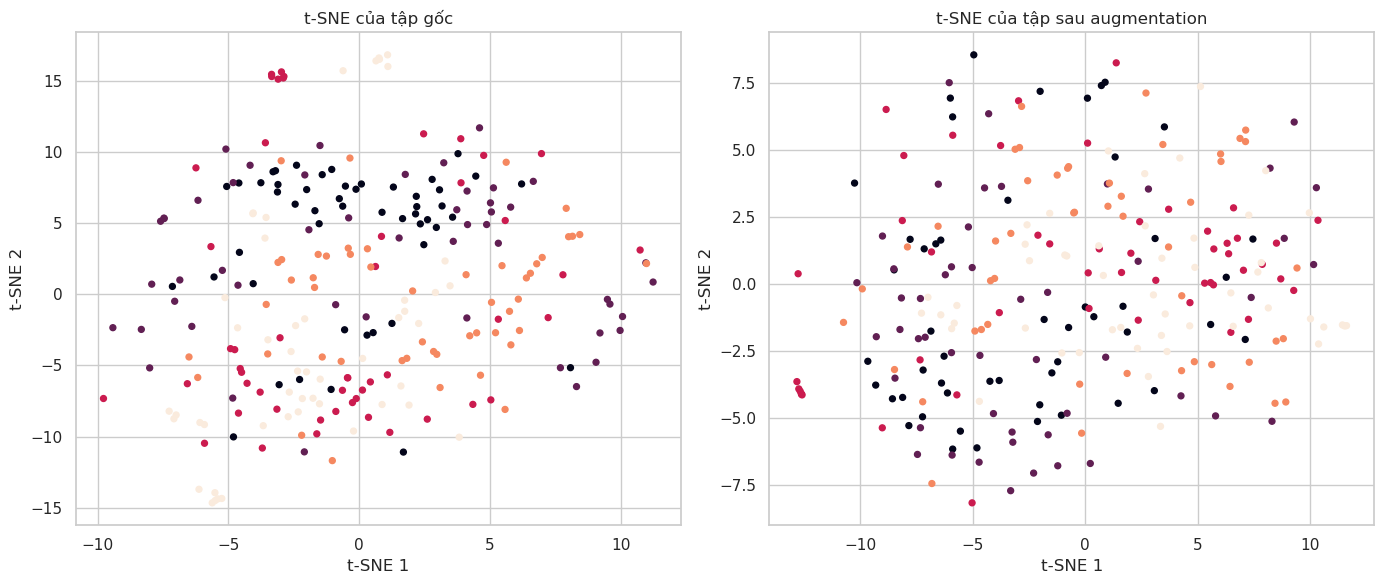

In [ ]:
tsne_df = (
    sample_df.groupby("label", group_keys=False)
    .head(50)
    .reset_index(drop=True)
)

X_original = []
X_augmented = []
y_tsne = []

for _, row in tsne_df.iterrows():
    img = read_rgb_image(row["image_path"])
    img = resize_np(img, 64)

    aug = augment_image(img)

    X_original.append(flatten_image(img))
    X_augmented.append(flatten_image(aug))
    y_tsne.append(row["label"])

X_original = np.array(X_original, dtype=np.float32)
X_augmented = np.array(X_augmented, dtype=np.float32)
y_tsne = np.array(y_tsne)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_tsne)

# Giảm chiều trước khi chạy t-SNE
pca_tsne = PCA(n_components=50, random_state=RANDOM_STATE)
X_original_pca = pca_tsne.fit_transform(X_original)
X_augmented_pca = pca_tsne.fit_transform(X_augmented)

tsne_original = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
tsne_augmented = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)

X_original_2d = tsne_original.fit_transform(X_original_pca)
X_augmented_2d = tsne_augmented.fit_transform(X_augmented_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_original_2d[:, 0], X_original_2d[:, 1], c=y_encoded, s=18)
axes[0].set_title("t-SNE của tập gốc")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

sc2 = axes[1].scatter(X_augmented_2d[:, 0], X_augmented_2d[:, 1], c=y_encoded, s=18)
axes[1].set_title("t-SNE của tập sau augmentation")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

#### Nhận xét

Kết quả trực quan hóa t-SNE cho thấy sự thay đổi rõ rệt trong phân phối đặc trưng sau khi áp dụng data augmentation.

Ở tập gốc, dữ liệu có xu hướng hình thành một số cấu trúc phân bố nhất định trong không gian đặc trưng, thể hiện qua việc các điểm tập trung theo các vùng tương đối rõ . Tuy nhiên, các lớp vẫn chồng lấn đáng kể và chưa được tách biệt rõ ràng.

Sau khi áp dụng augmentation, các điểm dữ liệu phân tán rộng hơn và bao phủ không gian đặc trưng một cách đồng đều hơn. Cấu trúc phân bố ban đầu bị làm mờ đi, cho thấy các phép biến đổi đã tạo ra nhiều biến thể khác nhau của ảnh, từ đó làm tăng độ đa dạng của dữ liệu.

Sự phân tán này giúp mở rộng không gian đặc trưng và có thể cải thiện khả năng tổng quát hóa của mô hình. Tuy nhiên, mức độ chồng lấn giữa các lớp vẫn còn, cho thấy augmentation không làm tăng đáng kể khả năng phân tách lớp mà chủ yếu đóng vai trò làm phong phú dữ liệu đầu vào. Do đó, data augmentation đóng vai trò hỗ trợ cải thiện hiệu quả mô hình, nhưng cần kết hợp với các bước tiền xử lý và mô hình hóa phù hợp để đạt hiệu quả phân loại tối ưu.

### 5. Ablation Study bằng k-NN

Tác động của các kỹ thuật tiền xử lý được đánh giá thông qua ablation study với mô hình phân loại **k-NN**. Mục tiêu là so sánh hiệu quả phân loại trước và sau khi lần lượt bổ sung từng kỹ thuật tiền xử lý vào pipeline đầu vào.

Thí nghiệm sử dụng **train/test split 80/20** và đánh giá kết quả bằng chỉ số **accuracy**.

Các kỹ thuật được xem xét trong ablation study gồm:
1. **Resize**
2. **Chuyển đổi không gian màu**
3. **Chuẩn hóa**
4. **Data augmentation**

Cách thiết kế này cho phép quan sát tác động riêng lẻ và tích lũy của từng kỹ thuật, từ đó xác định bước tiền xử lý nào đóng góp tích cực nhất vào hiệu quả phân loại.

In [ ]:
def build_feature_matrix(df, size=32, color_mode="rgb", normalization=None, use_augmentation=False):
    X, y = [], []

    for _, row in df.iterrows():
        img = read_rgb_image(row["image_path"])
        img = resize_np(img, size)

        if use_augmentation:
            img = augment_image(img)

        img = convert_color_space(img, color_mode)
        img = normalize_image(img, normalization)

        X.append(flatten_image(img))
        y.append(row["label"])

    return np.array(X, dtype=np.float32), np.array(y)


def evaluate_knn(
    df,
    size=32,
    color_mode="rgb",
    normalization=None,
    use_augmentation=False,
    n_neighbors=3
):
    # split trước
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=df["label"]
    )

    # train có thể augment
    X_train, y_train = build_feature_matrix(
        train_df,
        size=size,
        color_mode=color_mode,
        normalization=normalization,
        use_augmentation=use_augmentation
    )

    # test tuyệt đối không augment
    X_test, y_test = build_feature_matrix(
        test_df,
        size=size,
        color_mode=color_mode,
        normalization=normalization,
        use_augmentation=False
    )

    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    return float(accuracy_score(y_test, pred))

In [ ]:
ablation_results = []

acc_baseline = evaluate_knn(
    full_df,
    size=32,
    color_mode="rgb",
    normalization=None,
    use_augmentation=False
)
ablation_results.append({
    "pipeline": "Baseline (RGB, 32x32, no norm)",
    "accuracy": acc_baseline
})

acc_resize = evaluate_knn(
    full_df,
    size=128,
    color_mode="rgb",
    normalization=None,
    use_augmentation=False
)
ablation_results.append({
    "pipeline": "Baseline + Resize (128x128)",
    "accuracy": acc_resize
})

acc_color = evaluate_knn(
    full_df,
    size=128,
    color_mode="lab",
    normalization=None,
    use_augmentation=False
)
ablation_results.append({
    "pipeline": "Baseline + Resize + LAB",
    "accuracy": acc_color
})

acc_norm = evaluate_knn(
    full_df,
    size=128,
    color_mode="lab",
    normalization="zscore_channel",
    use_augmentation=False
)
ablation_results.append({
    "pipeline": "Baseline + Resize + LAB + Z-score per-channel",
    "accuracy": acc_norm
})

acc_aug = evaluate_knn(
    full_df,
    size=128,
    color_mode="lab",
    normalization="zscore_channel",
    use_augmentation=True
)
ablation_results.append({
    "pipeline": "Baseline + Resize + LAB + Z-score per-channel + Aug",
    "accuracy": acc_aug
})

ablation_df = pd.DataFrame(ablation_results)
ablation_df["improvement_vs_baseline"] = ablation_df["accuracy"] - ablation_df.iloc[0]["accuracy"]

ablation_df

,pipeline,accuracy,improvement_vs_baseline
0,"Baseline (RGB, 32x32, no norm)",0.655000,0.000000
1,Baseline + Resize (128x128),0.611667,-0.043333
2,Baseline + Resize + LAB,0.589167,-0.065833
3,Baseline + Resize + LAB + Z-score per-channel,0.673333,0.018333
4,Baseline + Resize + LAB + Z-score per-channel ...,0.547500,-0.107500


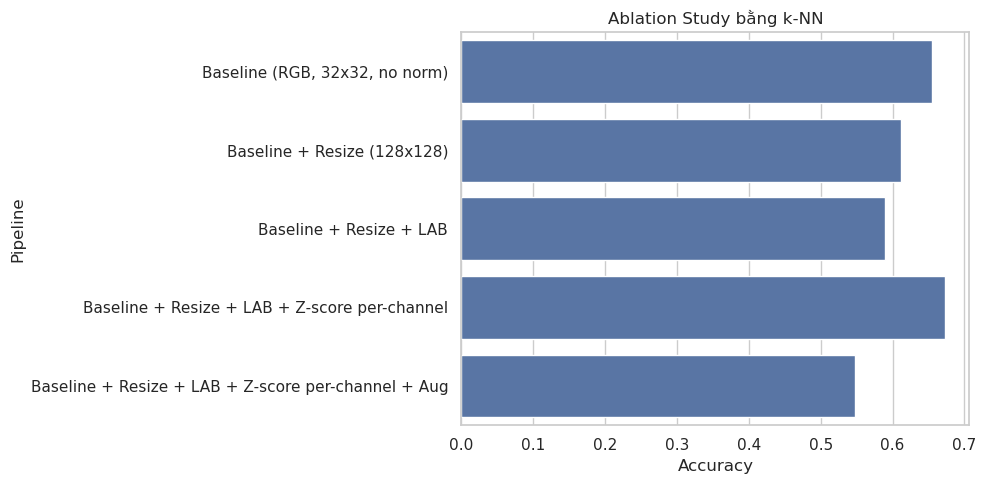

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=ablation_df, x="accuracy", y="pipeline")
plt.title("Ablation Study bằng k-NN")
plt.xlabel("Accuracy")
plt.ylabel("Pipeline")
plt.tight_layout()
plt.show()

#### Nhận xét

Kết quả ablation study cho thấy tác động của các kỹ thuật tiền xử lý không phải lúc nào cũng cải thiện hiệu quả phân loại.

Cụ thể, mô hình baseline đạt accuracy khoảng **0.655**. Khi tăng kích thước ảnh lên 128×128, accuracy giảm xuống **0.612**, cho thấy việc tăng độ phân giải không mang lại lợi ích trong trường hợp sử dụng k-NN với vector đặc trưng dạng flatten, do không khai thác được cấu trúc không gian của ảnh và làm tăng chiều dữ liệu.

Việc chuyển sang không gian màu LAB tiếp tục làm giảm hiệu năng (**0.589**), cho thấy thông tin màu trong không gian này chưa phù hợp với cách biểu diễn đặc trưng hiện tại.

Tuy nhiên, khi áp dụng **Z-score theo từng kênh**, accuracy tăng lên **0.673**, cao nhất trong các cấu hình đã thử. Điều này cho thấy chuẩn hóa giúp cân bằng phân phối dữ liệu giữa các kênh, từ đó cải thiện khả năng so sánh khoảng cách trong k-NN.

Ngược lại, khi bổ sung **data augmentation**, accuracy giảm mạnh xuống **0.548**. Nguyên nhân có thể do augmentation tạo ra các biến đổi làm thay đổi đặc trưng gốc quá nhiều, trong khi k-NN là mô hình nhạy với khoảng cách và không có khả năng học biểu diễn bền vững như các mô hình học sâu.

Tổng thể, kết quả cho thấy **chuẩn hóa là kỹ thuật mang lại cải thiện rõ rệt nhất**, trong khi resize và augmentation không phù hợp với pipeline hiện tại sử dụng k-NN và vector đặc trưng đơn giản.

### Bảng kết quả tổng hợp

In [ ]:
summary_213 = pd.DataFrame([
    {"metric": "selected_resize", "value": 128},

    {"metric": "best_color_space_by_pca",
     "value": color_space_df.loc[color_space_df["explained_variance_k50"].idxmax(), "color_space"]},

    {"metric": "best_color_space_explained_variance",
     "value": float(color_space_df["explained_variance_k50"].max())},

    {"metric": "recommended_normalization", "value": "zscore_channel"},

    {"metric": "augmentation_used",
     "value": "flip_h, flip_v, rotation, random_crop, gaussian_noise, brightness, contrast"},

    {"metric": "best_ablation_pipeline", "value": ablation_df.loc[ablation_df["accuracy"].idxmax(), "pipeline"]},

    {"metric": "best_ablation_accuracy", "value": float(ablation_df["accuracy"].max())},
])

summary_213

,metric,value
0,selected_resize,128
1,best_color_space_by_pca,gray
2,best_color_space_explained_variance,0.805262
3,recommended_normalization,zscore_channel
4,augmentation_used,"flip_h, flip_v, rotation, random_crop, gaussia..."
5,best_ablation_pipeline,Baseline + Resize + LAB + Z-score per-channel
6,best_ablation_accuracy,0.673333


### Kết luận

Phần phân tích đã đánh giá toàn diện tác động của các kỹ thuật tiền xử lý ảnh bao gồm **resize, chuyển đổi không gian màu, chuẩn hóa và data augmentation** thông qua các thước đo định lượng (**SSIM, PSNR, PCA, KS test, t-SNE**) và thực nghiệm phân loại với mô hình **k-NN**.

Kết quả cho thấy **việc tăng kích thước ảnh giúp bảo toàn thông tin tốt hơn**, thể hiện qua giá trị **SSIM và PSNR tăng dần theo kích thước**. Trong số các cấu hình đã thử, **128×128** đạt mức bảo toàn thông tin cao nhất và được lựa chọn cho các bước tiếp theo.

Trong phân tích không gian màu, **grayscale đạt explained variance cao nhất** khi áp dụng PCA, cho thấy **khả năng nén thông tin hiệu quả nhất**. Tuy nhiên, do **loại bỏ thông tin màu sắc**, không gian này **không phải là lựa chọn tối ưu cho bài toán phân loại**. Các không gian màu như **RGB hoặc LAB**, dù có explained variance thấp hơn, vẫn giữ được **thông tin màu quan trọng** và phù hợp hơn cho **downstream task**.

Kết quả chuẩn hóa cho thấy **tất cả các phương pháp đều làm thay đổi phân phối dữ liệu một cách có ý nghĩa thống kê**. Trong đó, **Z-score theo từng kênh** giúp **cân bằng phân phối giữa các kênh màu** và được xem là phương pháp **phù hợp nhất cho dữ liệu ảnh màu**.

Phân tích t-SNE cho thấy **data augmentation làm tăng độ phân tán và đa dạng của dữ liệu** trong không gian đặc trưng. Tuy nhiên, **mức độ chồng lấn giữa các lớp vẫn còn đáng kể**, cho thấy augmentation chủ yếu giúp **mở rộng không gian dữ liệu** hơn là **cải thiện khả năng phân tách lớp**.

Kết quả ablation study với mô hình **k-NN** cho thấy **không phải mọi kỹ thuật tiền xử lý đều cải thiện hiệu năng phân loại**. Cụ thể, **resize** và **chuyển đổi sang LAB** làm giảm accuracy, trong khi **Z-score theo từng kênh** giúp cải thiện hiệu năng và đạt kết quả tốt nhất (**accuracy ≈ 0.673**). Ngược lại, **data augmentation làm giảm đáng kể hiệu năng**, do tạo ra các biến thể làm sai lệch khoảng cách trong không gian đặc trưng, trong khi **k-NN là mô hình nhạy với khoảng cách**.

Tổng hợp lại, kết quả cho thấy **hiệu quả của các kỹ thuật tiền xử lý phụ thuộc mạnh vào mô hình sử dụng và cách biểu diễn đặc trưng**. Trong trường hợp sử dụng **k-NN với vector đặc trưng dạng flatten**, **chuẩn hóa là yếu tố quan trọng nhất**, trong khi **resize** hoặc **augmentation** không mang lại lợi ích rõ rệt. Điều này nhấn mạnh rằng **việc lựa chọn pipeline tiền xử lý cần được đánh giá dựa trên hiệu năng thực nghiệm**, thay vì chỉ dựa trên các chỉ số trung gian như khả năng bảo toàn thông tin.